In [1]:
# Standard Libraries
import math
import pickle
import random
import numpy as np

# Data Manipulation and Visualization
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
# matplotlib.use('Agg')  # For saving figures
import seaborn as sns
from sklearn.manifold import TSNE
from IPython.display import clear_output
from tqdm import tqdm

# Quantum Computing
import pennylane as qml

# PyTorch Libraries and Tools
import torch
import torch.nn as nn
from torch.autograd import Variable
from torch.utils.tensorboard import SummaryWriter
from torch.utils.data import DataLoader, TensorDataset

import importlib
from modules import QGAN, Discriminator, MINE  # 초기 import
importlib.reload(QGAN)  # 모듈 갱신
importlib.reload(Discriminator)  # 모듈 갱신
importlib.reload(MINE)  # 모듈 갱신

# Utility Functions
import kagglehub
from functools import reduce
import ndtest # 2D 분포 검정에 사용
from datetime import datetime
import os
import time
from modules.utils import convert_ipynb_to_html # 현재 html파일 저장을 위해 사용
import argparse
import json
from scipy.stats import ks_2samp

# for random forest
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix

train_type = "InfoQGAN"
use_mine = True if train_type == "InfoQGAN" else False
data_type = "IRIS"
data_legend_num = 3

n_qubits = 4
code_qubits = 1
output_qubits = n_qubits
noise_qubits = n_qubits - code_qubits

n_features = n_qubits

n_layers = 20
BATCH_SIZE = 16
SEED = 1
epoch_num = 300

G_lr = 0.003
D_lr = 0.0003
M_lr = 0.003
coeff = 0.01

range_l = 0.15
range_r = 0.85

c:\Users\minkyu\anaconda3\envs\quantum\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
train_data_df = None

if data_type == "IRIS":
    path = kagglehub.dataset_download("uciml/iris")
    print("Path to dataset files:", path)
    csv_file = os.path.join(path, "iris.csv")
    raw_data_df = pd.read_csv(csv_file)
elif data_type == "WINE":
    path = kagglehub.dataset_download("yasserh/wine-quality-dataset")
    print("Path to dataset files:", path)
    csv_file = os.path.join(path, "WineQT.csv")
    raw_data_df = pd.read_csv(csv_file)

print(raw_data_df.shape, raw_data_df.columns)

Path to dataset files: C:\Users\minkyu\.cache\kagglehub\datasets\uciml\iris\versions\2
(150, 6) Index(['Id', 'SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm',
       'Species'],
      dtype='object')


## Species 는 어떻게 처리할까
스칼라 하나로 처리해버리면 연속성 때문에 문제가 된다. 2차원이라면 되는데...
일단 species까지 drop하고 column 4개만 사용하자.

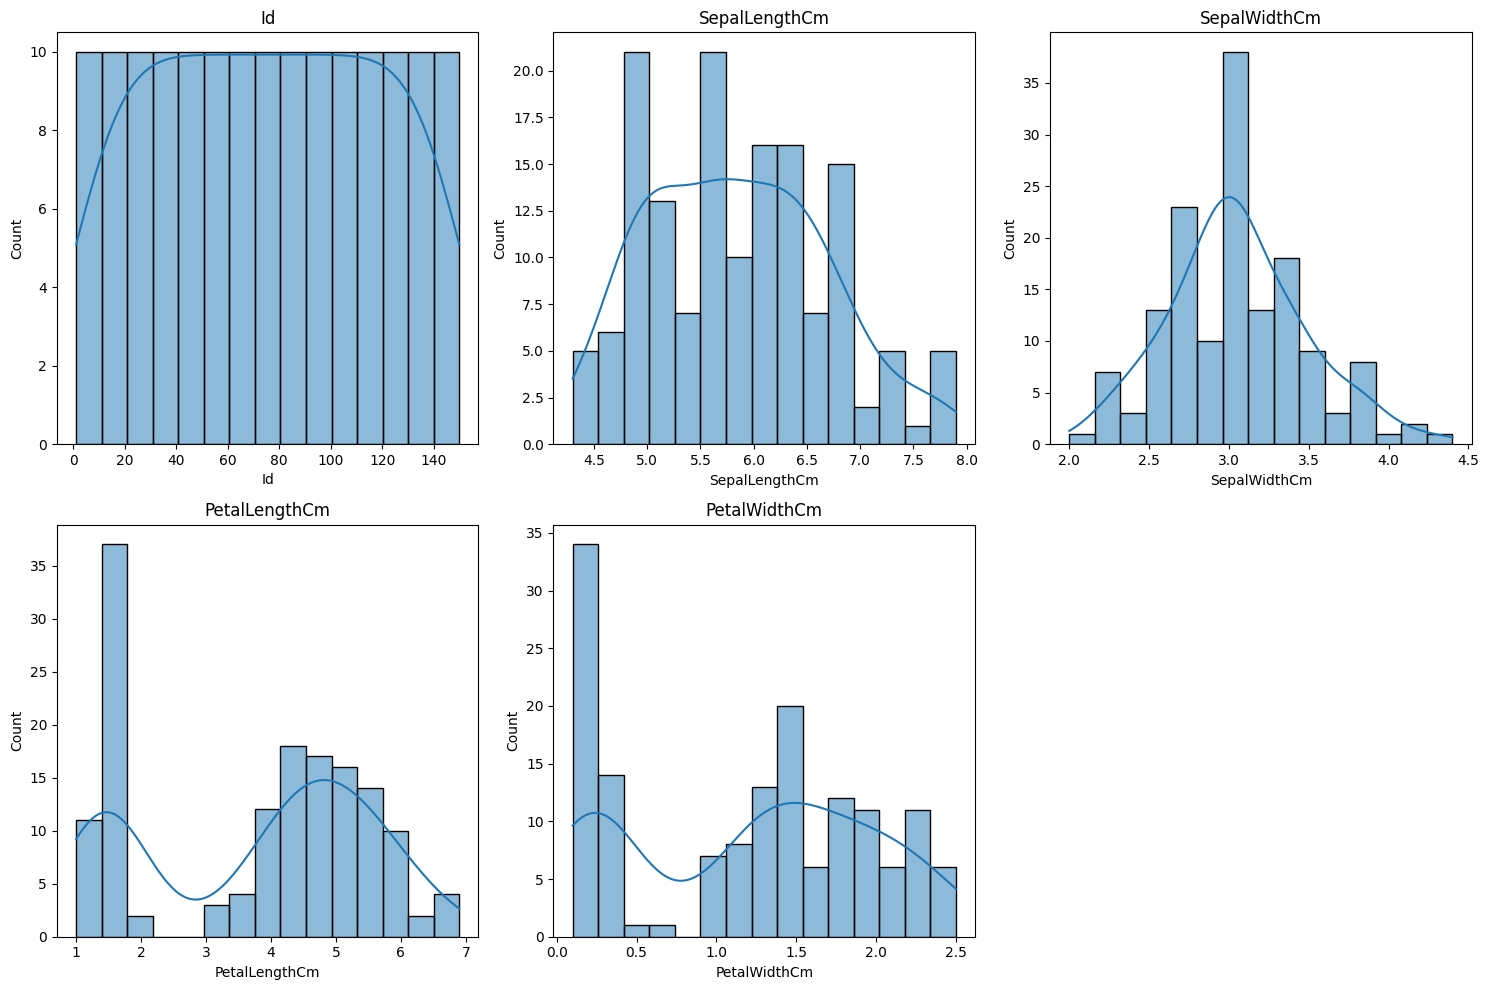

(150, 4)


In [3]:
# 수치형 변수 선택
numeric_cols = raw_data_df.select_dtypes(include=['float64', 'int64']).columns.tolist()

plt.figure(figsize=(15, 10))
for i, col in enumerate(numeric_cols):
    plt.subplot(math.ceil(len(numeric_cols) / 3), 3, i + 1)
    sns.histplot(raw_data_df[col], kde=True, bins=15)
    plt.title(col)
plt.tight_layout()
plt.show()

train_data_df = raw_data_df[numeric_cols]
train_data_df = train_data_df.drop(columns=['Id'])
train_data_np = train_data_df.to_numpy()
print(train_data_df.shape)

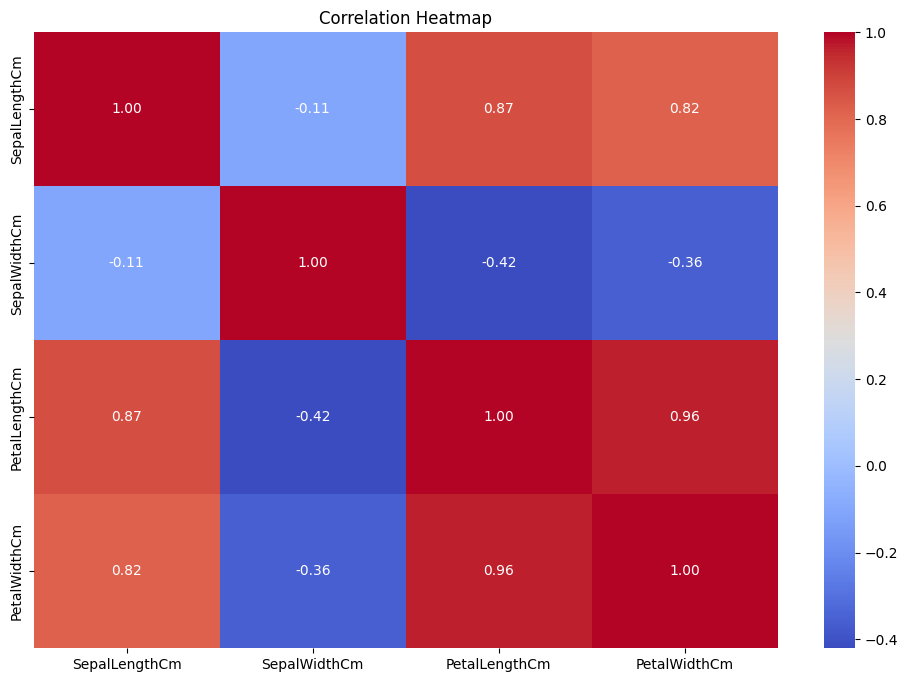

In [4]:
plt.figure(figsize=(12, 8))
corr = train_data_df.corr()
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()


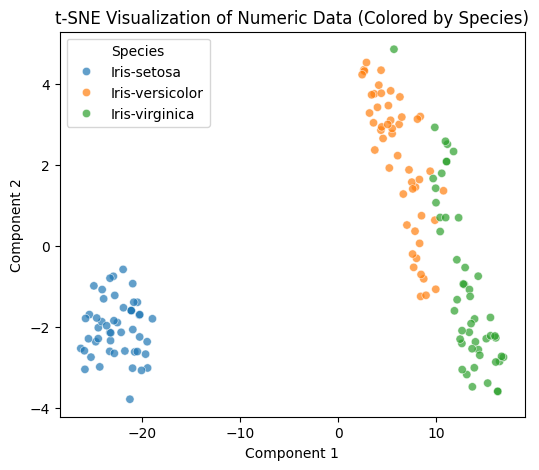

In [5]:
tsne = TSNE(n_components=2, random_state=42)
tsne_result = tsne.fit_transform(train_data_df.values)

# t-SNE 결과를 DataFrame으로 저장
tsne_df = pd.DataFrame(tsne_result, columns=['Component 1', 'Component 2'])
tsne_df['Species'] = raw_data_df['Species']

# t-SNE 결과를 시각화 (quality에 따른 색상 표시)
plt.figure(figsize=(6, 5))
sns.scatterplot(x='Component 1', y='Component 2', hue='Species', data=tsne_df, alpha=0.7)
plt.title("t-SNE Visualization of Numeric Data (Colored by Species)")
plt.legend(title='Species')
plt.show()

### Augmented 된 데이터도 정확히 이렇게 겹치게끔 하는게 목표이다.

일단 code qubit은 하나로? 그럼 virginica->versicolor->setosa 순으로 갔으면 좋겠는데


code qubit 입력은 불연속적으로 주어야 할듯

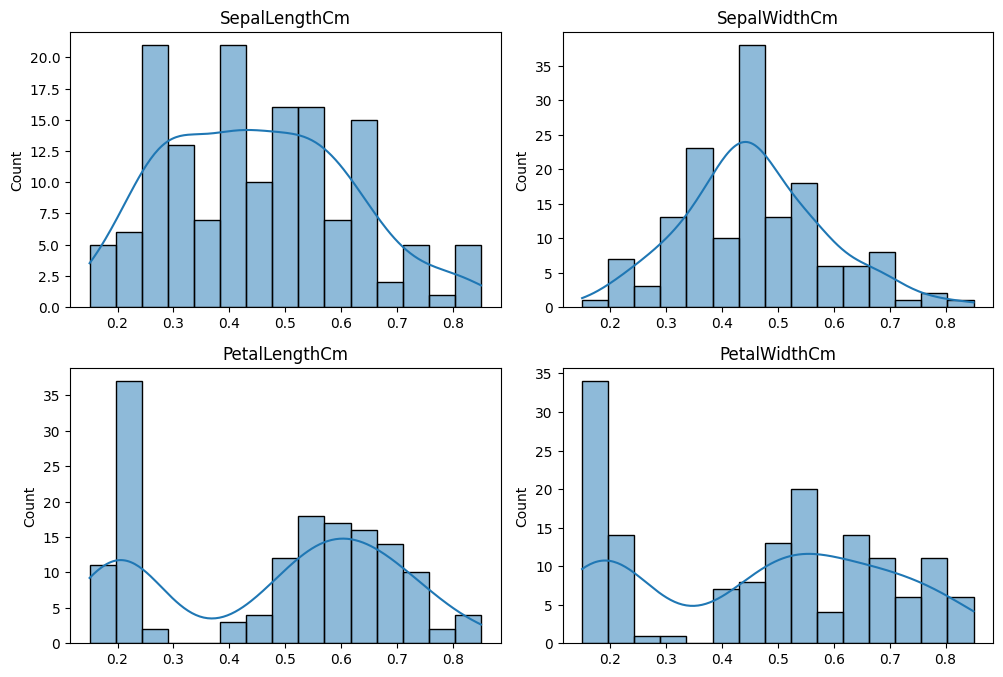

In [6]:
train_data_np = train_data_df.to_numpy()
min_val = train_data_np.min(axis=0)
max_val = train_data_np.max(axis=0)

# range_l ~ range_r 범위로 rescale
rescaled = range_l + (train_data_np - min_val) / (max_val - min_val) * (range_r - range_l)

plt.figure(figsize=(10, 10))
for i, col in enumerate(train_data_df.columns):
    plt.subplot(math.ceil(len(numeric_cols) / 2), 2, i + 1)
    sns.histplot(rescaled[:, i], kde=True, bins=15)
    plt.title(col)
plt.tight_layout()
plt.show()

train_tensor = torch.tensor(rescaled, dtype=torch.float32)

In [7]:
# setting torch device
ml_device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
quantum_device = qml.device("default.qubit", wires=n_qubits)
print("고전 머신러닝 device =", ml_device, "양자 회로 backend =", quantum_device)

# 생성자 파라미터 초기화 및 모듈 불러오기
generator_initial_params = Variable(torch.tensor(np.random.normal(-np.pi , np.pi, (n_layers, n_qubits, 1))), requires_grad=True)
generator = QGAN.QGAN2(n_qubits, output_qubits, n_layers, generator_initial_params, quantum_device)

# 판별자, MINE 초기화
discriminator = Discriminator.LinearDiscriminator(input_dim = output_qubits, hidden_size=128)
mine = MINE.LinearMine(code_dim=code_qubits, output_dim=output_qubits)

G_opt = torch.optim.Adam([generator.params], lr=G_lr)
D_opt = torch.optim.Adam(discriminator.parameters(), lr=D_lr)
M_opt = torch.optim.Adam(mine.parameters(), lr=M_lr)

고전 머신러닝 device = cpu 양자 회로 backend = <default.qubit device (wires=4) at 0x1caff4b67a0>


In [8]:
def bitwise_sums(arr):
    n = len(arr).bit_length() - 1  # 비트 길이를 계산하여 반복 횟수를 정함
    sums = torch.zeros(n, dtype=arr.dtype, device=arr.device)  # 결과를 저장할 텐서
    for bit in range(n):
        # 조건에 맞는 인덱스 선택을 위해 i-th 비트를 검사
        mask = (torch.arange(len(arr), device=arr.device) >> bit) & 1
        sums[bit] = arr[mask.bool()].sum()  # 조건에 맞는 원소들의 합산
    return sums

def output_postprocessing(arr):
    # arr: (BATCH_SIZE, output_qubits**2)
    # return: (BATCH_SIZE, output_qubits)
    ret = torch.stack([bitwise_sums(arr[i]) for i in range(len(arr))])
    return ret

def output_rescale(ret):
    # 원래 학습 데이터의 각 속성별 최소/최대값 추출
    train_mins = train_data_df.min()
    train_maxs = train_data_df.max()

    train_mins_tensor = torch.tensor(train_mins.values, dtype=ret.dtype, device=ret.device)
    train_maxs_tensor = torch.tensor(train_maxs.values, dtype=ret.dtype, device=ret.device)
                                     
    return train_mins_tensor + (ret - range_l) * (train_maxs_tensor - train_mins_tensor) / (range_r-range_l)

def generator_train_step(generator_input, use_mine = False):
    code_input = generator_input[:, :code_qubits] # 입력중에서 code만 뽑는다. (BATCH_SIZE, code_qubits)

    generator_output = generator.forward(generator_input) # 출력을 뽑아낸다 (BATCH_SIZE, 2**output_qubits)
    generator_output = output_postprocessing(generator_output) # (BATCH_SIZE, output_qubits)
    generator_output = generator_output.to(torch.float32) # (BATCH_SIZE, output_qubits)
    
    disc_output = discriminator(generator_output) # 평균과 표준편차 맞춘 뒤 판별자에 넣음
    gan_loss = torch.log(1-disc_output).mean()
    
    if use_mine:
        pred_xy = mine(code_input, generator_output)
        code_input_shuffle = code_input[torch.randperm(BATCH_SIZE)]
        pred_x_y = mine(code_input_shuffle, generator_output)
        mi = torch.mean(pred_xy) - torch.log(torch.mean(torch.exp(pred_x_y)))
        gan_loss -= coeff * mi

    return generator_output, gan_loss# TODO: 이건 분석용으로 넣어놓음.지워야 함.

disc_loss_fn = nn.BCELoss()
def disc_cost_fn(real_input, fake_input, smoothing=False):
    batch_num = real_input.shape[0]

    disc_real = discriminator(real_input)
    disc_fake = discriminator(fake_input)

    real_label = torch.ones((batch_num, 1)).to(ml_device)
    fake_label = torch.zeros((batch_num, 1)).to(ml_device)
    
    if smoothing:
        real_label = real_label - 0.2*torch.rand(real_label.shape).to(ml_device)
    
    loss = 0.5 * (disc_loss_fn(disc_real, real_label) + disc_loss_fn(disc_fake, fake_label))
    
    return loss

In [9]:
def categorical_distribution(S, E, T, size): # S~E를 T개로 내분하는 categorical distribution.
    if T == 1:
        categories = [(S+E)/2]
    else:
        categories = np.linspace(S, E, T)
    return torch.tensor(np.random.choice(categories, size))

def combined_tsne(origin_df, generated_data_df):
    origin_df = origin_df.copy()
    # 두 DataFrame을 합침 (Species 컬럼 포함)
    origin_df["Species"] = raw_data_df["Species"]
    combined_df = pd.concat([origin_df, generated_data_df], axis=0, ignore_index=True)
    tsne_result = TSNE(n_components=2, random_state=42).fit_transform(
        combined_df.drop("Species", axis=1).values
    )
    combined_df["Component 1"] = tsne_result[:, 0]
    combined_df["Component 2"] = tsne_result[:, 1]
    # 시각화
    fig = plt.figure(figsize=(6, 5))
    sns.scatterplot(
        x="Component 1", y="Component 2", hue="Species",
        data=combined_df, alpha=0.7
    )
    plt.title("t-SNE Visualization of Origin&Generated")
    plt.legend(title="Species")
    return fig


def visualize_output_augment(log_gen_outputs, log_gen_codes, epoch, writer, image_file_path):
    # 1. 첫 번째 플롯: 출력의 hisplot
    fig1 = plt.figure(figsize=(10, 10))
    for i, col in enumerate(train_data_df.columns):
        plt.subplot(math.ceil(n_features / 2), 2, i + 1)
        sns.histplot(log_gen_outputs[:, i], kde=True, bins=15)
        plt.title(f"{col}")
    plt.tight_layout()

    # 2. 두 번째 플롯: 출력의 상관관계 heatmap
    fig2 = plt.figure(figsize=(12, 8))
    corr = np.corrcoef(log_gen_outputs, rowvar=False)
    sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
    plt.title("Correlation Heatmap")

    # 세 번째 플롯: t-SNE 시각화
    output_df = pd.DataFrame(log_gen_outputs, columns=train_data_df.columns)
    categories = np.linspace(-SEED, SEED, data_legend_num)
    mapping = {float(cat): f'Class {i+1}' for i, cat in enumerate(categories)}
    gen_codes_categories = np.array(log_gen_codes[:, 0]).flatten()
    output_df['Species'] = pd.Series(gen_codes_categories).map(mapping)
    fig3 = combined_tsne(train_data_df, output_df)

    # TensorBoard에 기록
    writer.add_figure(f'hisplot', fig1, epoch)
    writer.add_figure(f'heatmap', fig2, epoch)
    writer.add_figure(f'tsnes', fig3, epoch)
    # fig1, fig2, fig3 를 image file로 저장
    fig1.savefig(f'{image_file_path}/hist_epoch_{epoch}.png')
    fig2.savefig(f'{image_file_path}/corr_epoch_{epoch}.png')
    fig3.savefig(f'{image_file_path}/tsne_epoch_{epoch}.png')

    # 메모리 관리를 위해 plt를 닫음
    plt.close(fig1)
    plt.close(fig2)
    plt.close(fig3)

In [10]:
current_time = datetime.now().strftime("%b%d_%H_%M_%S")  # "Aug13_14_12" 형식
trial_name = f"IRIS_{train_type}_nq{n_qubits}_nl{n_layers}_{current_time}"
save_dir = f"./runs/{trial_name}"
scalar_save_path = os.path.join(save_dir, f"{trial_name}.csv")
image_save_dir = os.path.join(save_dir, "images")
numpy_save_dir = os.path.join(save_dir, "numpy")
param_save_dir = os.path.join(save_dir, "params")
os.makedirs(image_save_dir, exist_ok=True)
os.makedirs(numpy_save_dir, exist_ok=True)
os.makedirs(param_save_dir, exist_ok=True)

convert_ipynb_to_html('augment_train.ipynb', os.path.join(save_dir, "augment_train.html"))

# CSV 파일 초기화 (헤더 작성)
if not os.path.exists(scalar_save_path):
    df = pd.DataFrame(columns=['epoch', 'D_loss', 'G_loss', 'MI', 'time'] + 
                  [f'Corr/code{i}-{axis}' for i in range(code_qubits) for axis in train_data_df.columns] +
                  [f'{feature_name}_D_ks' for feature_name in train_data_df.columns] +
                  [f'{feature_name}_p_value' for feature_name in train_data_df.columns])

# TensorBoard SummaryWriter 초기화
writer = SummaryWriter(log_dir=save_dir)

start_time = time.time()

train_loader = DataLoader(
    TensorDataset(train_tensor),
    batch_size=BATCH_SIZE,
    shuffle=True,
    pin_memory=True,
    drop_last=True  # 마지막 배치 크기가 작으면 무시
)

for epoch in range(1, epoch_num+1):
    G_loss_sum = 0.0
    D_loss_sum = 0.0
    mi_sum = 0.0
    batch_num = len(train_tensor) // BATCH_SIZE
    pbar = tqdm(train_loader, desc=f"Epoch {epoch}/{epoch_num}", unit="batch")

    # 그림 그릴때 필요하다
    gen_outputs = [] # (데이터수, n_features) QGAN으로 생성한 데이터
    gen_codes = [] # (데이터수, code_qubits) 점 찍는데 들어간 code들

    for batch_idx, (batch,) in enumerate(pbar):  # batch unpacking
        # train generator
        #TODO: 불연속 데이터로 code input 주자.
        generator_seed = torch.empty((BATCH_SIZE, n_qubits)).uniform_(-SEED, SEED).to(ml_device) # 실제 범위 = +-SEED * np.pi/2.
        generator_seed[:, 0] = categorical_distribution(-SEED, SEED, data_legend_num, BATCH_SIZE)
        generator_output, generator_loss = generator_train_step(generator_seed, use_mine=use_mine)
        G_opt.zero_grad()
        generator_loss.requires_grad_(True)
        generator_loss.backward()
        G_opt.step()
        
        # train discriminator
        fake_input = generator_output.detach().to(torch.float32)
        disc_loss = disc_cost_fn(batch, fake_input, smoothing=False)
        D_opt.zero_grad()
        disc_loss.requires_grad_(True)
        disc_loss.backward()
        D_opt.step()

        # train mine
        code_input = generator_seed[:, :code_qubits] # (BATCH_SIZE, code_qubits) 코드만 추출
        pred_xy = mine(code_input, fake_input)
        code_input_shuffle = code_input[torch.randperm(BATCH_SIZE)]
        pred_x_y = mine(code_input_shuffle, fake_input)
        mi = -torch.mean(pred_xy) + torch.log(torch.mean(torch.exp(pred_x_y)))
        M_opt.zero_grad()
        mi.requires_grad_(True)
        mi.backward()
        M_opt.step()

        D_loss_sum += disc_loss.item()
        G_loss_sum += generator_loss.item()
        mi_sum -= mi.item() # (-1)곱해져 있어서 빼야함.

        gen_outputs.append(output_rescale(fake_input).numpy()) # 실제 데이터 범위로 늘린 후 저장
        gen_codes.append(code_input.numpy())

        pbar.set_postfix({'G_loss': G_loss_sum/(batch_idx+1), 'D_loss': D_loss_sum/(batch_idx+1), 'MI': mi_sum/(batch_idx+1)})

    # G_scheduler.step()
    # D_scheduler.step()
    # M_scheduler.step()
    
    gen_outputs = np.concatenate(gen_outputs, axis=0) # (train_num, n_features)

    gen_codes = np.concatenate(gen_codes, axis=0) # (train_num, 2)

    D_loss, G_loss, mi = D_loss_sum/batch_num, G_loss_sum/batch_num, mi_sum/batch_num

    writer.add_scalar('Loss/d_loss', D_loss, epoch)
    writer.add_scalar('Loss/g_loss', G_loss, epoch)
    writer.add_scalar('Loss/mi', mi, epoch)
    D_ks_dict = {}
    p_value_dict = {}
    for i in range(n_features):
        stat, p_value = ks_2samp(gen_outputs[:, i], train_data_np[:, i])
        feature_name = train_data_df.columns[i]
        writer.add_scalar(f'D_ks/{feature_name}', stat, epoch)
        writer.add_scalar(f'p_value/{feature_name}', p_value, epoch)
        D_ks_dict[f'{feature_name}_D_ks'] = stat
        p_value_dict[f'{feature_name}_p_value'] = p_value
    

    correlation_matrix = np.zeros((code_qubits, n_features))      # 각 code와 basis state간의 상관관계
    for i in range(code_qubits):
        for j in range(n_features):
            correlation_matrix[i, j] = np.corrcoef(gen_codes[:, i], gen_outputs[:, j])[0, 1]
            writer.add_scalar(f'Corr/code{i}-{train_data_df.columns[j]}', correlation_matrix[i, j], epoch)

    # calculation all angle between correlation_matrix[i, :] and correlation_matrix[j, :]
    angle_sum = 0
    for i in range(code_qubits):
        for j in range(i+1, code_qubits):
            cos_theta = np.dot(correlation_matrix[i, :], correlation_matrix[j, :]) / (np.linalg.norm(correlation_matrix[i, :]) * np.linalg.norm(correlation_matrix[j, :]))
            theta_degrees = np.degrees(np.arccos(np.clip(cos_theta, -1.0, 1.0)))
            theta_degrees = min(theta_degrees, 180 - theta_degrees) # 예각으로 변환
            writer.add_scalar(f'Angle/angle{i}-{j}', theta_degrees, epoch)
            angle_sum += theta_degrees

    if code_qubits > 1:
        angle_avg = angle_sum / (code_qubits * (code_qubits - 1) / 2)
        writer.add_scalar('Angle/Code_Angle', angle_avg, epoch)

    # 스칼라 값 CSV로 덮어쓰기 저장
    file_exists = os.path.isfile(scalar_save_path)
    new_data = pd.DataFrame({
        'epoch': [epoch],
        'D_loss': [D_loss],
        'G_loss': [G_loss],
        'MI': [mi],
        **D_ks_dict,
        **p_value_dict,
        'time': [int((time.time() - start_time)*1000)],
        **{f'Corr/code{i}-{axis}': [correlation_matrix[i, j]] for i in range(code_qubits) for j, axis in enumerate(train_data_df.columns)},
    })

    new_data.to_csv(scalar_save_path, mode='a',  header=not file_exists)
    
    visualize_output_augment(gen_outputs, gen_codes, epoch, writer, image_save_dir) # save fig here

    # 각 epoch마다 numpy의 savetxt를 사용하여 저장
    output_file_path = os.path.join(numpy_save_dir, f"gen_outputs_epoch_{epoch}.txt")
    codes_file_path = os.path.join(numpy_save_dir, f"gen_codes_epoch_{epoch}.txt")

    np.savetxt(output_file_path, gen_outputs)
    np.savetxt(codes_file_path, gen_codes)
    torch.save(generator.params, f'{param_save_dir}/generator_params_epoch{epoch}.pth') # QGAN 파라미터 저장

HTML 파일이 ./runs/IRIS_InfoQGAN_nq4_nl20_Feb22_12_59_06\augment_train.html에 저장되었습니다.


Epoch 7/300:  89%|████████▉ | 8/9 [00:09<00:01,  1.24s/batch, G_loss=-0.717, D_loss=0.691, MI=0.0486]


KeyboardInterrupt: 

In [ ]:
log_gen_codes.shape

NameError: name 'log_gen_codes' is not defined